# PlantCLEF 2015 Two-Stage Species Diagnostics

This notebook does not train new models. It restores the same LeafScan paper60 data, loads saved VGG16 S-CNN(A/B) checkpoints from Google Drive, then checks whether the weak species result comes from the genus gate, S-CNN(B), score mode, aggregation, or checkpoint choice.


## 1. Runtime Check

Use a GPU runtime. The diagnostics only run inference, but the all-reference oracle can still be slow on CPU.


In [5]:
import torch

print('CUDA:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')


CUDA: True
Device: NVIDIA L4


## 2. Clone Or Update Project


In [11]:
from pathlib import Path
import os
import shutil
import subprocess

PROJECT_DIR = Path('/content/diploma')
REPO_URL = 'https://github.com/robodanill/diploma.git'
BRANCH = 'robodanill/main'


def clone_project():
    os.chdir('/content')
    if PROJECT_DIR.exists():
        shutil.rmtree(PROJECT_DIR)
    subprocess.run(['git', 'clone', '-b', BRANCH, REPO_URL, str(PROJECT_DIR)], check=True)


def pull_project() -> bool:
    if not (PROJECT_DIR / '.git').exists():
        return False
    result = subprocess.run(['git', 'pull', '--ff-only'], cwd=PROJECT_DIR)
    return result.returncode == 0


if PROJECT_DIR.exists():
    print(f'Trying to update existing project: {PROJECT_DIR}')
    if not pull_project():
        print('Pull failed or project is not a git repository; cloning a fresh copy.')
        clone_project()
else:
    print(f'Project not found at {PROJECT_DIR}; cloning a fresh copy.')
    clone_project()

os.chdir(PROJECT_DIR)
subprocess.run(['python', '-m', 'pip', 'install', '-e', '.[ml]'], check=True)

commit = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], cwd=PROJECT_DIR, text=True).strip()
print(f'Project commit: {commit}')


Trying to update existing project: /content/diploma
Project commit: 0aff7f1


## 3. Mount Google Drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive')


## 4. Restore LeafScan Data And Paper60 Metadata

Expected archives on Drive:

- `/content/drive/MyDrive/PlantCLEF2015_leafscan_only.tar.gz`
- `/content/drive/MyDrive/PlantCLEF2015_leafscan_test.tar.gz`

The cell rebuilds `leafscan_paper60_metadata.csv` from official test species and adds rotation-based rows only for species with fewer than six training images, matching the training notebook setup.


In [ ]:
%%bash
set -euo pipefail
trap 'echo "FAILED at line $LINENO: $BASH_COMMAND" >&2' ERR
export PYTHONUNBUFFERED=1
cd /content/diploma

ARCHIVE=/content/drive/MyDrive/PlantCLEF2015_leafscan_only.tar.gz
TEST_ARCHIVE=/content/drive/MyDrive/PlantCLEF2015_leafscan_test.tar.gz

echo "checking required archives"
ls -lh /content/drive/MyDrive/PlantCLEF2015*.tar.gz 2>/dev/null || true
if [ ! -f "$ARCHIVE" ]; then
  echo "Missing LeafScan training archive: $ARCHIVE" >&2
  exit 2
fi
if [ ! -f "$TEST_ARCHIVE" ]; then
  echo "Missing LeafScan test archive: $TEST_ARCHIVE" >&2
  exit 3
fi

rm -rf data/plantclef2015
mkdir -p data/plantclef2015

echo "extracting training archive: $ARCHIVE"
tar -xzf "$ARCHIVE" -C data/plantclef2015
test -f data/plantclef2015/leafscan/metadata.csv
cp data/plantclef2015/leafscan/metadata.csv data/plantclef2015/leafscan_metadata.csv

echo "extracting test archive: $TEST_ARCHIVE"
rm -rf data/plantclef2015/test_leafscan
mkdir -p data/plantclef2015/test_leafscan
tar -xzf "$TEST_ARCHIVE" -C data/plantclef2015/test_leafscan
test -f data/plantclef2015/test_leafscan/leafscan/metadata.csv
cp data/plantclef2015/test_leafscan/leafscan/metadata.csv data/plantclef2015/test_leafscan_metadata.csv

python - <<'PY2'
import csv
from collections import Counter, defaultdict
from pathlib import Path
from PIL import Image

with open('data/plantclef2015/leafscan_metadata.csv', newline='', encoding='utf-8') as file:
    source_rows = list(csv.DictReader(file))
with open('data/plantclef2015/test_leafscan_metadata.csv', newline='', encoding='utf-8') as file:
    test_rows = list(csv.DictReader(file))

test_species = {row['species'] for row in test_rows}
paper60_rows = [row for row in source_rows if row['species'] in test_species]
source_species = {row['species'] for row in source_rows}
missing_in_train = sorted(test_species - source_species)
if missing_in_train:
    raise RuntimeError(f'Missing test species in train metadata: {missing_in_train}')

fieldnames = list(source_rows[0].keys())
with open('data/plantclef2015/leafscan_paper60_metadata.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(paper60_rows)

train_count_by_species = Counter(row['species'] for row in paper60_rows)
underfilled_species = sorted(species for species in test_species if train_count_by_species[species] < 6)
if underfilled_species:
    print('paper60 species with fewer than 6 train images:', underfilled_species)
    rows_by_species = defaultdict(list)
    for row in paper60_rows:
        rows_by_species[row['species']].append(row)
    augmented_dir = Path('data/plantclef2015/leafscan/augmented')
    augmented_dir.mkdir(parents=True, exist_ok=True)
    leafscan_root = Path('data/plantclef2015/leafscan')
    angles = [180, 90, 270, 15, -15]
    augmented_rows = []
    for species in underfilled_species:
        species_rows = rows_by_species[species]
        if not species_rows:
            raise RuntimeError(f'Cannot augment {species}: no train rows found')
        needed = 6 - len(species_rows)
        for index in range(needed):
            base_row = species_rows[index % len(species_rows)]
            source_path = Path(base_row['image_path'])
            if not source_path.is_absolute():
                source_path = leafscan_root / source_path
            angle = angles[index % len(angles)]
            output_name = f"{source_path.stem}_aug_rot{angle}_{index + 1}.jpg".replace('-', 'm')
            output_path = augmented_dir / output_name
            with Image.open(source_path) as image:
                image.convert('RGB').rotate(angle, expand=True, fillcolor=(255, 255, 255)).save(output_path, quality=95)
            augmented_row = dict(base_row)
            augmented_row['image_path'] = str(output_path.relative_to(leafscan_root))
            if 'source_xml' in augmented_row:
                augmented_row['source_xml'] = f"{augmented_row['source_xml']}#aug_rot{angle}"
            augmented_rows.append(augmented_row)
    paper60_rows.extend(augmented_rows)
    with open('data/plantclef2015/leafscan_paper60_metadata.csv', 'w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(paper60_rows)
    print('paper60 augmented rows added:', len(augmented_rows))

train_count_by_species = Counter(row['species'] for row in paper60_rows)
underfilled_species = sorted(species for species in test_species if train_count_by_species[species] < 6)
if underfilled_species:
    raise RuntimeError(f'Cannot build 6-shot paper subset: {underfilled_species}')

print('leafscan source rows:', len(source_rows))
print('paper60 train rows:', len(paper60_rows))
print('paper60 train genera:', len({row['genus'] for row in paper60_rows}))
print('paper60 train species:', len({row['species'] for row in paper60_rows}))
paper60_species_by_genus = defaultdict(set)
test_species_by_genus = defaultdict(set)
for row in paper60_rows:
    paper60_species_by_genus[row['genus']].add(row['species'])
for row in test_rows:
    test_species_by_genus[row['genus']].add(row['species'])
paper60_species_per_genus = {genus: len(species) for genus, species in paper60_species_by_genus.items()}
test_species_per_genus = {genus: len(species) for genus, species in test_species_by_genus.items()}
print('paper60 max species per genus:', max(paper60_species_per_genus.values()))
print('paper60 genera with >6 species:', sorted(g for g, count in paper60_species_per_genus.items() if count > 6))
print('paper60 test rows:', len(test_rows))
print('paper60 test genera:', len({row['genus'] for row in test_rows}))
print('paper60 test species:', len(test_species))
print('paper60 test max species per genus:', max(test_species_per_genus.values()))
print('paper60 test genera with >6 species:', sorted(g for g, count in test_species_per_genus.items() if count > 6))
print('paper60 six-shot training rows:', 6 * len(test_species))
print('smallest train species counts:', train_count_by_species.most_common()[-10:])
PY2


## 5. Locate VGG16 S-CNN Checkpoints On Drive

By default this copies the newest VGG16 genus/species best and final checkpoints from `/content/drive/MyDrive/diploma_checkpoints` to `/content/diploma/checkpoints`. Set `MANUAL_CHECKPOINTS` if a specific run should be used.


In [7]:
from pathlib import Path
import json
import shutil as shutil_module

MANUAL_CHECKPOINTS = {
    'genus_best': '',
    'genus_final': '',
    'species_best': '',
    'species_final': '',
}
DRIVE_CHECKPOINT_ROOT = Path('/content/drive/MyDrive/diploma_checkpoints')
LOCAL_CHECKPOINT_ROOT = Path('/content/diploma/checkpoints')
LOCAL_CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

PATTERNS = {
    'genus_best': [
        'leafscan_vgg16/**/scnn_genus_vgg16_best.pt',
        '**/scnn_genus_vgg16_best.pt',
    ],
    'genus_final': [
        'leafscan_vgg16/**/scnn_genus_vgg16.pt',
        'scnn_genus_vgg16.pt',
        '**/scnn_genus_vgg16.pt',
    ],
    'species_best': [
        'leafscan_vgg16/**/scnn_species_vgg16_best.pt',
        '**/scnn_species_vgg16_best.pt',
    ],
    'species_final': [
        'leafscan_vgg16/**/scnn_species_vgg16.pt',
        'scnn_species_vgg16.pt',
        '**/scnn_species_vgg16.pt',
    ],
}
LOCAL_NAMES = {
    'genus_best': 'scnn_genus_vgg16_best.pt',
    'genus_final': 'scnn_genus_vgg16.pt',
    'species_best': 'scnn_species_vgg16_best.pt',
    'species_final': 'scnn_species_vgg16.pt',
}


def newest_checkpoint(patterns):
    candidates = []
    for pattern in patterns:
        candidates.extend(DRIVE_CHECKPOINT_ROOT.glob(pattern))
    candidates = sorted(set(candidates), key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f'No checkpoint found under {DRIVE_CHECKPOINT_ROOT} for patterns={patterns}')
    return candidates[0]

selected = {}
for key, patterns in PATTERNS.items():
    source = Path(MANUAL_CHECKPOINTS[key]) if MANUAL_CHECKPOINTS[key] else newest_checkpoint(patterns)
    if not source.exists():
        raise FileNotFoundError(source)
    target = LOCAL_CHECKPOINT_ROOT / LOCAL_NAMES[key]
    shutil_module.copy2(source, target)
    selected[key] = str(target)
    print(f'{key}: {source} -> {target} ({target.stat().st_size} bytes)')

paths_file = Path('/content/diploma/.vgg16_checkpoint_paths.json')
paths_file.write_text(json.dumps(selected, indent=2), encoding='utf-8')
print('Saved checkpoint map:', paths_file)


genus_best: /content/drive/MyDrive/diploma_checkpoints/leafscan_vgg16/genus_20260523T150311Z_6283/scnn_genus_vgg16_best.pt -> /content/diploma/checkpoints/scnn_genus_vgg16_best.pt (537071831 bytes)
genus_final: /content/drive/MyDrive/diploma_checkpoints/leafscan_vgg16/genus_20260523T150311Z_6283/scnn_genus_vgg16.pt -> /content/diploma/checkpoints/scnn_genus_vgg16.pt (537071641 bytes)
species_best: /content/drive/MyDrive/diploma_checkpoints/leafscan_vgg16/species_20260523T155211Z_2585/scnn_species_vgg16_best.pt -> /content/diploma/checkpoints/scnn_species_vgg16_best.pt (537071971 bytes)
species_final: /content/drive/MyDrive/diploma_checkpoints/leafscan_vgg16/species_20260523T155211Z_2585/scnn_species_vgg16.pt -> /content/diploma/checkpoints/scnn_species_vgg16.pt (537071717 bytes)
Saved checkpoint map: /content/diploma/.vgg16_checkpoint_paths.json


## 6. Compare S-CNN(A) Best/Final Checkpoints

This repeats genus retrieval for best and final genus checkpoints with both comparator and raw L1 scoring.


In [ ]:
from pathlib import Path
import json
import subprocess

PROJECT_DIR = Path('/content/diploma')
paths = json.loads((PROJECT_DIR / '.vgg16_checkpoint_paths.json').read_text(encoding='utf-8'))
TOP_K = ['5', '15', '30', '50']

for label in ['genus_best', 'genus_final']:
    for score_mode in ['comparator', 'l1']:
        print(f'\n=== {label} score_mode={score_mode} ===')
        cmd = [
            'python', '-u', '-m', 'plant_classifier.training.eval_genus_cli',
            '--config', 'configs/leafscan_paper60_training.yaml',
            '--query-config', 'configs/leafscan_test.yaml',
            '--checkpoint', paths[label],
            '--max-species', '0',
            '--references-per-genus', '6',
            '--reference-level', 'genus',
            '--reference-seed', '42',
            '--reference-split', 'train',
            '--score-mode', score_mode,
            '--top-k', *TOP_K,
        ]
        subprocess.run(cmd, cwd=PROJECT_DIR, check=True)


## 7. Compare Two-Stage Best/Final Checkpoint Combos

This checks whether the weak two-stage species result is just a best/final checkpoint mismatch.


In [ ]:
from pathlib import Path
import json
import subprocess

PROJECT_DIR = Path('/content/diploma')
paths = json.loads((PROJECT_DIR / '.vgg16_checkpoint_paths.json').read_text(encoding='utf-8'))

for genus_label in ['genus_best', 'genus_final']:
    for species_label in ['species_best', 'species_final']:
        print(f'\n=== genus={genus_label} species={species_label} current two-stage settings ===')
        cmd = [
            'python', '-u', '-m', 'plant_classifier.training.eval_species_cli',
            '--config', 'configs/leafscan_paper60_training.yaml',
            '--query-config', 'configs/leafscan_test.yaml',
            '--genus-checkpoint', paths[genus_label],
            '--species-checkpoint', paths[species_label],
            '--genus-references-per-genus', '6',
            '--references-per-species', '6',
            '--genus-candidates', '30',
            '--reference-seed', '42',
            '--reference-split', 'train',
            '--genus-score-mode', 'l1',
            '--species-score-mode', 'comparator',
            '--species-aggregation', 'max',
            '--top-k', '1', '3', '5',
        ]
        subprocess.run(cmd, cwd=PROJECT_DIR, check=True)


## 8. Species-Only Oracle And Two-Stage Grid

`genus_candidates=258` uses all genus references, so the genus gate is effectively disabled. If those rows are still weak, S-CNN(B) or the local-view representation is the bottleneck. The grid also compares comparator vs L1 for both stages, max/mean/sum species aggregation, and two genus-gate variants: the current top-reference mode and a unique-genus mode that keeps the first occurrence of each genus.


In [12]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

OUT_DIR="/content/drive/MyDrive/diploma_diagnostics/species_vgg16_grid_$(date -u +%Y%m%dT%H%M%SZ)"
mkdir -p "$OUT_DIR"

python -u -m plant_classifier.training.eval_species_grid_cli \
  --config configs/leafscan_paper60_training.yaml \
  --query-config configs/leafscan_test.yaml \
  --genus-checkpoint checkpoints/scnn_genus_vgg16_best.pt \
  --species-checkpoint checkpoints/scnn_species_vgg16_best.pt \
  --genus-references-per-genus 6 \
  --references-per-species 6 \
  --reference-seed 42 \
  --reference-split train \
  --genus-candidates 5 10 15 30 50 100 258 \
  --genus-candidate-modes reference unique \
  --genus-weight-modes frequency score uniform \
  --include-gold-genus-oracle \
  --genus-score-modes comparator l1 \
  --species-score-modes comparator l1 \
  --species-aggregations max mean sum \
  --top-k 1 3 5 \
  --output-csv "$OUT_DIR/species_grid_summary.csv" \
  --print-top 40

ls -lh "$OUT_DIR"


using reference subset: 360 images from 60 species
genus_references=258 species_references=360 queries=221 device=cuda
query species distribution: {'Ruscus aculeatus L.': 25, 'Acer campestre L.': 13, 'Ginkgo biloba L.': 9, 'Hedera helix L.': 9, 'Castanea sativa Mill.': 9, 'Viburnum opulus L.': 9, 'Fraxinus excelsior L.': 9, "Lippia triphylla (L'Hér.) Kuntze": 7, 'Fraxinus angustifolia Vahl': 7, 'Betula pendula Roth': 6}
reference pool species per genus: {'Acer': 6, 'Quercus': 4, 'Fraxinus': 3, 'Populus': 3, 'Prunus': 3, 'Crataegus': 2, 'Tilia': 2, 'Viburnum': 2, 'Ailanthus': 1, 'Alnus': 1}
genus reference species coverage: {'Acer': '6/6', 'Quercus': '4/4', 'Fraxinus': '3/3', 'Populus': '3/3', 'Prunus': '3/3', 'Crataegus': '2/2', 'Tilia': '2/2', 'Viburnum': '2/2', 'Ailanthus': '1/1', 'Alnus': '1/1'}
embedding references and queries once
precomputing genus and species scores
=== best grid rows ===
candidate_mode=gold_genus genus_candidates=0 genus_candidate_mode=gold genus_weight_mode=go

## 9. Read The Latest Grid Summary


In [13]:
from pathlib import Path
import pandas as pd

base = Path('/content/drive/MyDrive/diploma_diagnostics')
latest = sorted(base.glob('species_vgg16_grid_*'), key=lambda path: path.stat().st_mtime, reverse=True)[0]
summary = pd.read_csv(latest / 'species_grid_summary.csv')
if 'candidate_mode' not in summary.columns:
    summary['candidate_mode'] = 'ranked_genus'
if 'genus_candidate_mode' not in summary.columns:
    summary['genus_candidate_mode'] = 'reference'
if 'genus_weight_mode' not in summary.columns:
    summary['genus_weight_mode'] = 'frequency'
cols = [
    'candidate_mode',
    'genus_candidates',
    'genus_candidate_mode',
    'genus_weight_mode',
    'genus_score_mode',
    'species_score_mode',
    'species_aggregation',
    'genus_gate_accuracy',
    'top1',
    'top3',
    'top5',
    'plantclef_s',
]
display(summary[cols].head(25))
print('latest grid:', latest)
print('best practical ranked-genus rows:')
display(
    summary.loc[summary['candidate_mode'] == 'ranked_genus', cols]
    .sort_values(['plantclef_s', 'top5', 'top1'], ascending=False)
    .head(20)
)
print('best unique-genus rows:')
display(
    summary.loc[
        (summary['candidate_mode'] == 'ranked_genus')
        & (summary['genus_candidate_mode'] == 'unique'),
        cols,
    ]
    .sort_values(['plantclef_s', 'top5', 'top1'], ascending=False)
    .head(20)
)
print('reference-mode rows, genus_candidates=15/30:')
display(
    summary.loc[
        (summary['candidate_mode'] == 'ranked_genus')
        & (summary['genus_candidate_mode'] == 'reference')
        & (summary['genus_candidates'].astype(str).isin(['15', '30'])),
        cols,
    ].sort_values(['plantclef_s', 'top5'], ascending=False).head(20)
)
print('species-only oracle rows, genus_candidates=258:')
display(
    summary.loc[
        (summary['candidate_mode'] == 'ranked_genus') & (summary['genus_candidates'].astype(str) == '258'),
        cols,
    ].sort_values(['plantclef_s', 'top5'], ascending=False).head(20)
)
print('gold-genus oracle rows:')
display(
    summary.loc[summary['candidate_mode'] == 'gold_genus', cols]
    .sort_values(['plantclef_s', 'top5'], ascending=False)
)


,candidate_mode,genus_candidates,genus_candidate_mode,genus_weight_mode,genus_score_mode,species_score_mode,species_aggregation,genus_gate_accuracy,top1,top3,top5,plantclef_s
0,gold_genus,0,gold,gold,gold,comparator,max,1.000000,0.737557,0.932127,1.000000,0.837179
1,gold_genus,0,gold,gold,gold,l1,max,1.000000,0.733032,0.932127,1.000000,0.834389
2,gold_genus,0,gold,gold,gold,l1,mean,1.000000,0.723982,0.936652,1.000000,0.830468
3,gold_genus,0,gold,gold,gold,l1,sum,1.000000,0.723982,0.936652,1.000000,0.830468
4,gold_genus,0,gold,gold,gold,comparator,mean,1.000000,0.728507,0.932127,0.990950,0.829336
5,gold_genus,0,gold,gold,gold,comparator,sum,1.000000,0.728507,0.932127,0.990950,0.829336
6,ranked_genus,15,reference,frequency,l1,l1,max,0.746606,0.244344,0.434389,0.556561,0.384592
7,ranked_genus,30,reference,frequency,l1,l1,max,0.809955,0.239819,0.434389,0.542986,0.378332
8,ranked_genus,50,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
9,ranked_genus,100,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318


latest grid: /content/drive/MyDrive/diploma_diagnostics/species_vgg16_grid_20260523T170019Z
best practical ranked-genus rows:


,candidate_mode,genus_candidates,genus_candidate_mode,genus_weight_mode,genus_score_mode,species_score_mode,species_aggregation,genus_gate_accuracy,top1,top3,top5,plantclef_s
6,ranked_genus,15,reference,frequency,l1,l1,max,0.746606,0.244344,0.434389,0.556561,0.384592
7,ranked_genus,30,reference,frequency,l1,l1,max,0.809955,0.239819,0.434389,0.542986,0.378332
8,ranked_genus,50,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
9,ranked_genus,100,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
10,ranked_genus,258,reference,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
11,ranked_genus,258,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
12,ranked_genus,10,unique,score,l1,l1,mean,0.809955,0.230769,0.438914,0.565611,0.374310
13,ranked_genus,10,unique,score,l1,l1,sum,0.809955,0.230769,0.438914,0.565611,0.374310
14,ranked_genus,30,unique,score,comparator,l1,max,0.923077,0.244344,0.416290,0.511312,0.372810
15,ranked_genus,15,reference,score,l1,l1,mean,0.746606,0.230769,0.443439,0.565611,0.372755


best unique-genus rows:


,candidate_mode,genus_candidates,genus_candidate_mode,genus_weight_mode,genus_score_mode,species_score_mode,species_aggregation,genus_gate_accuracy,top1,top3,top5,plantclef_s
8,ranked_genus,50,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
9,ranked_genus,100,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
11,ranked_genus,258,unique,score,comparator,l1,max,1.000000,0.244344,0.416290,0.511312,0.374318
12,ranked_genus,10,unique,score,l1,l1,mean,0.809955,0.230769,0.438914,0.565611,0.374310
13,ranked_genus,10,unique,score,l1,l1,sum,0.809955,0.230769,0.438914,0.565611,0.374310
14,ranked_genus,30,unique,score,comparator,l1,max,0.923077,0.244344,0.416290,0.511312,0.372810
19,ranked_genus,15,unique,score,l1,l1,mean,0.864253,0.226244,0.447964,0.556561,0.372197
20,ranked_genus,15,unique,score,l1,l1,sum,0.864253,0.226244,0.447964,0.556561,0.372197
30,ranked_genus,15,unique,score,comparator,l1,max,0.814480,0.244344,0.416290,0.511312,0.369091
31,ranked_genus,10,unique,score,l1,l1,max,0.809955,0.226244,0.425339,0.547511,0.366779


...

,candidate_mode,genus_candidates,genus_candidate_mode,genus_weight_mode,genus_score_mode,species_score_mode,species_aggregation,genus_gate_accuracy,top1,top3,top5,plantclef_s
6,ranked_genus,15,reference,frequency,l1,l1,max,0.746606,0.244344,0.434389,0.556561,0.384592
7,ranked_genus,30,reference,frequency,l1,l1,max,0.809955,0.239819,0.434389,0.542986,0.378332
15,ranked_genus,15,reference,score,l1,l1,mean,0.746606,0.230769,0.443439,0.565611,0.372755
16,ranked_genus,15,reference,score,l1,l1,sum,0.746606,0.230769,0.443439,0.565611,0.372755
17,ranked_genus,30,reference,score,l1,l1,mean,0.809955,0.230769,0.443439,0.565611,0.372734
18,ranked_genus,30,reference,score,l1,l1,sum,0.809955,0.230769,0.443439,0.565611,0.372734
24,ranked_genus,15,reference,frequency,l1,comparator,max,0.746606,0.217195,0.452489,0.556561,0.371246
27,ranked_genus,15,reference,score,l1,l1,max,0.746606,0.230769,0.434389,0.552036,0.370541
33,ranked_genus,30,reference,frequency,l1,comparator,mean,0.809955,0.235294,0.402715,0.547511,0.366123
34,ranked_genus,30,reference,frequency,l1,comparator,sum,0.809955,0.235294,0.402715,0.547511,0.366123


species-only oracle rows, genus_candidates=258:


,candidate_mode,genus_candidates,genus_candidate_mode,genus_weight_mode,genus_score_mode,species_score_mode,species_aggregation,genus_gate_accuracy,top1,top3,top5,plantclef_s
10,ranked_genus,258,reference,score,comparator,l1,max,1.0,0.244344,0.416290,0.511312,0.374318
11,ranked_genus,258,unique,score,comparator,l1,max,1.0,0.244344,0.416290,0.511312,0.374318
56,ranked_genus,258,reference,score,l1,l1,mean,1.0,0.221719,0.429864,0.520362,0.358898
57,ranked_genus,258,reference,score,l1,l1,sum,1.0,0.221719,0.429864,0.520362,0.358898
58,ranked_genus,258,unique,score,l1,l1,mean,1.0,0.221719,0.429864,0.520362,0.358898
59,ranked_genus,258,unique,score,l1,l1,sum,1.0,0.221719,0.429864,0.520362,0.358898
69,ranked_genus,258,reference,score,comparator,l1,mean,1.0,0.217195,0.402715,0.511312,0.354719
70,ranked_genus,258,reference,score,comparator,l1,sum,1.0,0.217195,0.402715,0.511312,0.354719
71,ranked_genus,258,unique,score,comparator,l1,mean,1.0,0.217195,0.402715,0.511312,0.354719
72,ranked_genus,258,unique,score,comparator,l1,sum,1.0,0.217195,0.402715,0.511312,0.354719


gold-genus oracle rows:


,candidate_mode,genus_candidates,genus_candidate_mode,genus_weight_mode,genus_score_mode,species_score_mode,species_aggregation,genus_gate_accuracy,top1,top3,top5,plantclef_s
0,gold_genus,0,gold,gold,gold,comparator,max,1.0,0.737557,0.932127,1.00000,0.837179
1,gold_genus,0,gold,gold,gold,l1,max,1.0,0.733032,0.932127,1.00000,0.834389
2,gold_genus,0,gold,gold,gold,l1,mean,1.0,0.723982,0.936652,1.00000,0.830468
3,gold_genus,0,gold,gold,gold,l1,sum,1.0,0.723982,0.936652,1.00000,0.830468
4,gold_genus,0,gold,gold,gold,comparator,mean,1.0,0.728507,0.932127,0.99095,0.829336
5,gold_genus,0,gold,gold,gold,comparator,sum,1.0,0.728507,0.932127,0.99095,0.829336


## 10. Plot Grid Summary For Draft

Creates draft-ready plots from the latest grid CSV: metric curves by `genus_candidates` and a compact bar chart of the best settings. Files are saved next to `species_grid_summary.csv` on Drive.


In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

base = Path('/content/drive/MyDrive/diploma_diagnostics')
latest = sorted(base.glob('species_vgg16_grid_*'), key=lambda path: path.stat().st_mtime, reverse=True)[0]
summary = pd.read_csv(latest / 'species_grid_summary.csv')
if 'candidate_mode' not in summary.columns:
    summary['candidate_mode'] = 'ranked_genus'
if 'genus_candidate_mode' not in summary.columns:
    summary['genus_candidate_mode'] = 'reference'
if 'genus_weight_mode' not in summary.columns:
    summary['genus_weight_mode'] = 'frequency'
summary['genus_candidates_num'] = pd.to_numeric(summary['genus_candidates'], errors='coerce')

ranked = summary.loc[summary['candidate_mode'] == 'ranked_genus'].copy()
focus = ranked.loc[
    (ranked['genus_score_mode'] == 'l1')
    & (ranked['species_score_mode'] == 'l1')
    & (ranked['species_aggregation'] == 'max')
    & (ranked['genus_candidate_mode'].isin(['reference', 'unique']))
    & (ranked['genus_weight_mode'].isin(['frequency', 'score']))
].copy()

fig, ax = plt.subplots(figsize=(8, 4.5))
for (candidate_mode, weight_mode), group in focus.groupby(['genus_candidate_mode', 'genus_weight_mode']):
    group = group.sort_values('genus_candidates_num').drop_duplicates(['genus_candidates_num'])
    ax.plot(
        group['genus_candidates_num'],
        group['plantclef_s'],
        marker='o',
        label=f'{candidate_mode}/{weight_mode}',
    )
ax.set_xlabel('genus candidates')
ax.set_ylabel('PlantCLEF S')
ax.set_ylim(0, 1)
ax.set_title('Two-stage S-CNN grid: genus gate variants')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
curve_path = latest / 'species_grid_genus_gate_variants.png'
fig.savefig(curve_path, dpi=180)
plt.close(fig)

best = summary.sort_values(['plantclef_s', 'top5', 'top1'], ascending=False).head(10).copy()
best['label'] = best.apply(
    lambda row: (
        f"{row['candidate_mode']}\nR={row['genus_candidates']} "
        f"{row.get('genus_candidate_mode', 'reference')}/{row.get('genus_weight_mode', 'frequency')}\n"
        f"{row['genus_score_mode']}/{row['species_score_mode']}/{row['species_aggregation']}"
    ),
    axis=1,
)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(range(len(best)), best['plantclef_s'], color='#0f766e')
ax.set_ylim(0, max(0.55, best['plantclef_s'].max() + 0.05))
ax.set_ylabel('PlantCLEF S')
ax.set_title('Best two-stage S-CNN settings')
ax.set_xticks(range(len(best)))
ax.set_xticklabels(best['label'], rotation=45, ha='right', fontsize=8)
for index, value in enumerate(best['plantclef_s']):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=8)
fig.tight_layout()
bars_path = latest / 'species_grid_best_settings.png'
fig.savefig(bars_path, dpi=180)
plt.close(fig)

print('Saved:', curve_path)
print('Saved:', bars_path)


Saved: /content/drive/MyDrive/diploma_diagnostics/species_vgg16_grid_20260523T161303Z/species_grid_l1_l1_mean_curves.png
Saved: /content/drive/MyDrive/diploma_diagnostics/species_vgg16_grid_20260523T161303Z/species_grid_best_settings.png


## 11. Save Confusion Matrix For Best Practical Settings

Runs full two-stage evaluation with the best practical configuration from the grid and writes the same PNG/CSV artifact set as the training notebook: confusion matrix, top-k chart, rank histogram, per-species top-1 chart, predictions, and summary.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

OUT_DIR="/content/drive/MyDrive/diploma_diagnostics/species_vgg16_best_reference_frequency_R15_$(date -u +%Y%m%dT%H%M%SZ)"
mkdir -p "$OUT_DIR"

python -u -m plant_classifier.training.eval_species_cli \
  --config configs/leafscan_paper60_training.yaml \
  --query-config configs/leafscan_test.yaml \
  --genus-checkpoint checkpoints/scnn_genus_vgg16_best.pt \
  --species-checkpoint checkpoints/scnn_species_vgg16_best.pt \
  --genus-references-per-genus 6 \
  --references-per-species 6 \
  --genus-candidates 15 \
  --genus-candidate-mode reference \
  --genus-weight-mode frequency \
  --reference-seed 42 \
  --reference-split train \
  --genus-score-mode l1 \
  --species-score-mode l1 \
  --species-aggregation max \
  --output-dir "$OUT_DIR" \
  --top-k 1 3 5

ls -lh "$OUT_DIR"


## 12. Plot Training Loss From Notebook Outputs

This is for draft figures from already executed notebooks. If the repository copy of `plantclef_colab_training.ipynb` has outputs, the cell extracts epoch loss, best loss, and any logged train/validation accuracy curves into PNG and CSV files on Drive. If Colab cloned a clean notebook, save/export the executed training notebook to Drive and set `TRAINING_NOTEBOOK_PATH` to that file.


In [ ]:
from pathlib import Path
import json
import re
import matplotlib.pyplot as plt
import pandas as pd

TRAINING_NOTEBOOK_PATH = Path('/content/diploma/notebooks/plantclef_colab_training.ipynb')
FALLBACK_NOTEBOOK_PATHS = [
    Path('/content/drive/MyDrive/plantclef_colab_training.ipynb'),
    Path('/content/drive/MyDrive/PlantCLEF/plantclef_colab_training.ipynb'),
]
for candidate in [TRAINING_NOTEBOOK_PATH, *FALLBACK_NOTEBOOK_PATHS]:
    if candidate.exists():
        TRAINING_NOTEBOOK_PATH = candidate
        break

if not TRAINING_NOTEBOOK_PATH.exists():
    raise FileNotFoundError('Training notebook not found; set TRAINING_NOTEBOOK_PATH to the executed notebook file')

nb = json.loads(TRAINING_NOTEBOOK_PATH.read_text(encoding='utf-8'))
rows = []
heading = ''
for cell in nb.get('cells', []):
    src = ''.join(cell.get('source', []))
    first = src.splitlines()[0] if src.splitlines() else ''
    if cell.get('cell_type') == 'markdown' and first.startswith('##'):
        heading = first.lstrip('#').strip()
    if cell.get('cell_type') != 'code':
        continue
    output_text = ''.join(
        ''.join(output.get('text', []))
        for output in cell.get('outputs', [])
        if 'text' in output
    )
    for line in output_text.splitlines():
        match = re.search(r'epoch=(\d+)\s+loss=([0-9.]+)\s+best_loss=([0-9.]+)', line)
        if not match:
            continue
        row = {
            'section': heading or 'unknown',
            'epoch': int(match.group(1)),
            'loss': float(match.group(2)),
            'best_loss': float(match.group(3)),
        }
        for metric in [
            'train_accuracy',
            'top1_genus_accuracy',
            'top3_genus_accuracy',
            'top5_genus_accuracy',
            'best_top5',
        ]:
            metric_match = re.search(metric + r'=([0-9.]+)', line)
            if metric_match:
                row[metric] = float(metric_match.group(1))
        rows.append(row)

if not rows:
    raise RuntimeError(
        f'No epoch loss lines found in {TRAINING_NOTEBOOK_PATH}. '
        'Use a notebook file with saved outputs or run this in the executed training notebook.'
    )

history = pd.DataFrame(rows)
out_dir = Path('/content/drive/MyDrive/diploma_diagnostics/training_curves')
out_dir.mkdir(parents=True, exist_ok=True)
history_path = out_dir / 'training_history_from_notebook.csv'
history.to_csv(history_path, index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
for section, group in history.groupby('section'):
    if 'Full VGG16 Train' not in section and 'Baseline' not in section:
        continue
    ax.plot(group['epoch'], group['loss'], marker='o', linewidth=1.4, label=section.replace('`', ''))
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('Training loss curves')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
loss_path = out_dir / 'training_loss_curves.png'
fig.savefig(loss_path, dpi=180)
plt.close(fig)

accuracy_columns = [column for column in ['train_accuracy', 'top1_genus_accuracy', 'top3_genus_accuracy', 'top5_genus_accuracy'] if column in history.columns]
if accuracy_columns:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for section, group in history.groupby('section'):
        for column in accuracy_columns:
            values = group.dropna(subset=[column])
            if not values.empty:
                ax.plot(values['epoch'], values[column], marker='o', linewidth=1.3, label=f'{section}: {column}')
    ax.set_xlabel('epoch')
    ax.set_ylabel('accuracy')
    ax.set_ylim(0, 1)
    ax.set_title('Logged training/validation accuracy')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7)
    fig.tight_layout()
    acc_path = out_dir / 'training_accuracy_curves.png'
    fig.savefig(acc_path, dpi=180)
    plt.close(fig)
    print('Saved:', acc_path)
else:
    print('No accuracy columns found in epoch summary lines')

print('Saved:', history_path)
print('Saved:', loss_path)
display(history.tail(10))


## 13. Display Draft Figures Inline

Run this after sections `10-12` to show the generated PNG figures directly in the notebook. It uses the latest matching artifact folders on Google Drive and skips files that have not been created yet.


### Grid summary

Directory: `/content/drive/MyDrive/diploma_diagnostics/species_vgg16_grid_20260521T054841Z`

`/content/drive/MyDrive/diploma_diagnostics/species_vgg16_grid_20260521T054841Z/species_grid_l1_l1_mean_curves.png` not found

`/content/drive/MyDrive/diploma_diagnostics/species_vgg16_grid_20260521T054841Z/species_grid_best_settings.png` not found

### Best practical S-CNN result: R=15, L1/L1/mean

...

### Training curves

No artifact directory found yet.

### Previous two-stage evaluation artifacts

Directory: `/content/drive/MyDrive/diploma_diagnostics/species_vgg16_20260521T000620Z`

`/content/drive/MyDrive/diploma_diagnostics/species_vgg16_20260521T000620Z/topk_species_accuracy.png`

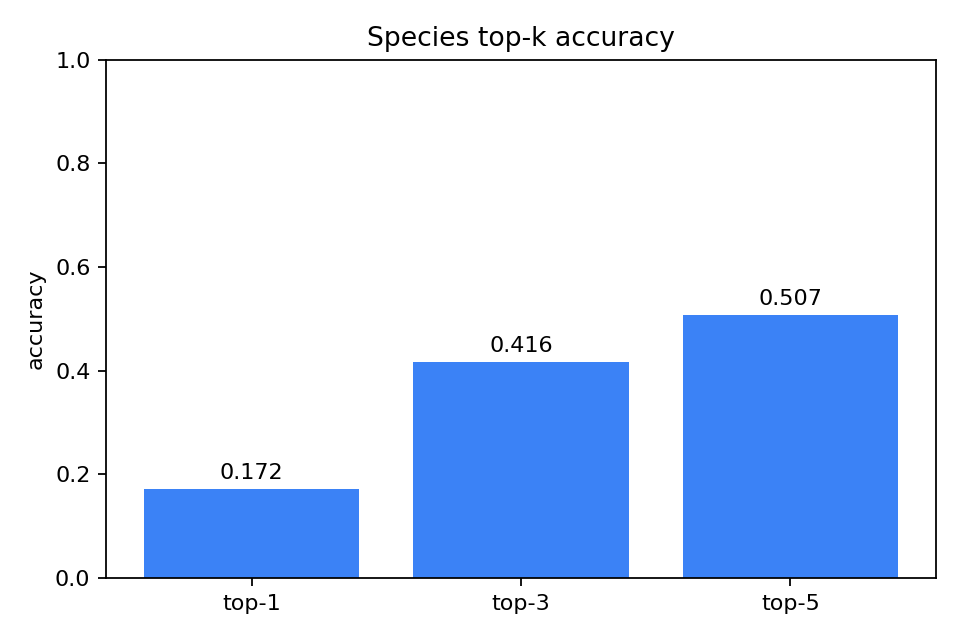

`/content/drive/MyDrive/diploma_diagnostics/species_vgg16_20260521T000620Z/species_confusion_matrix.png`

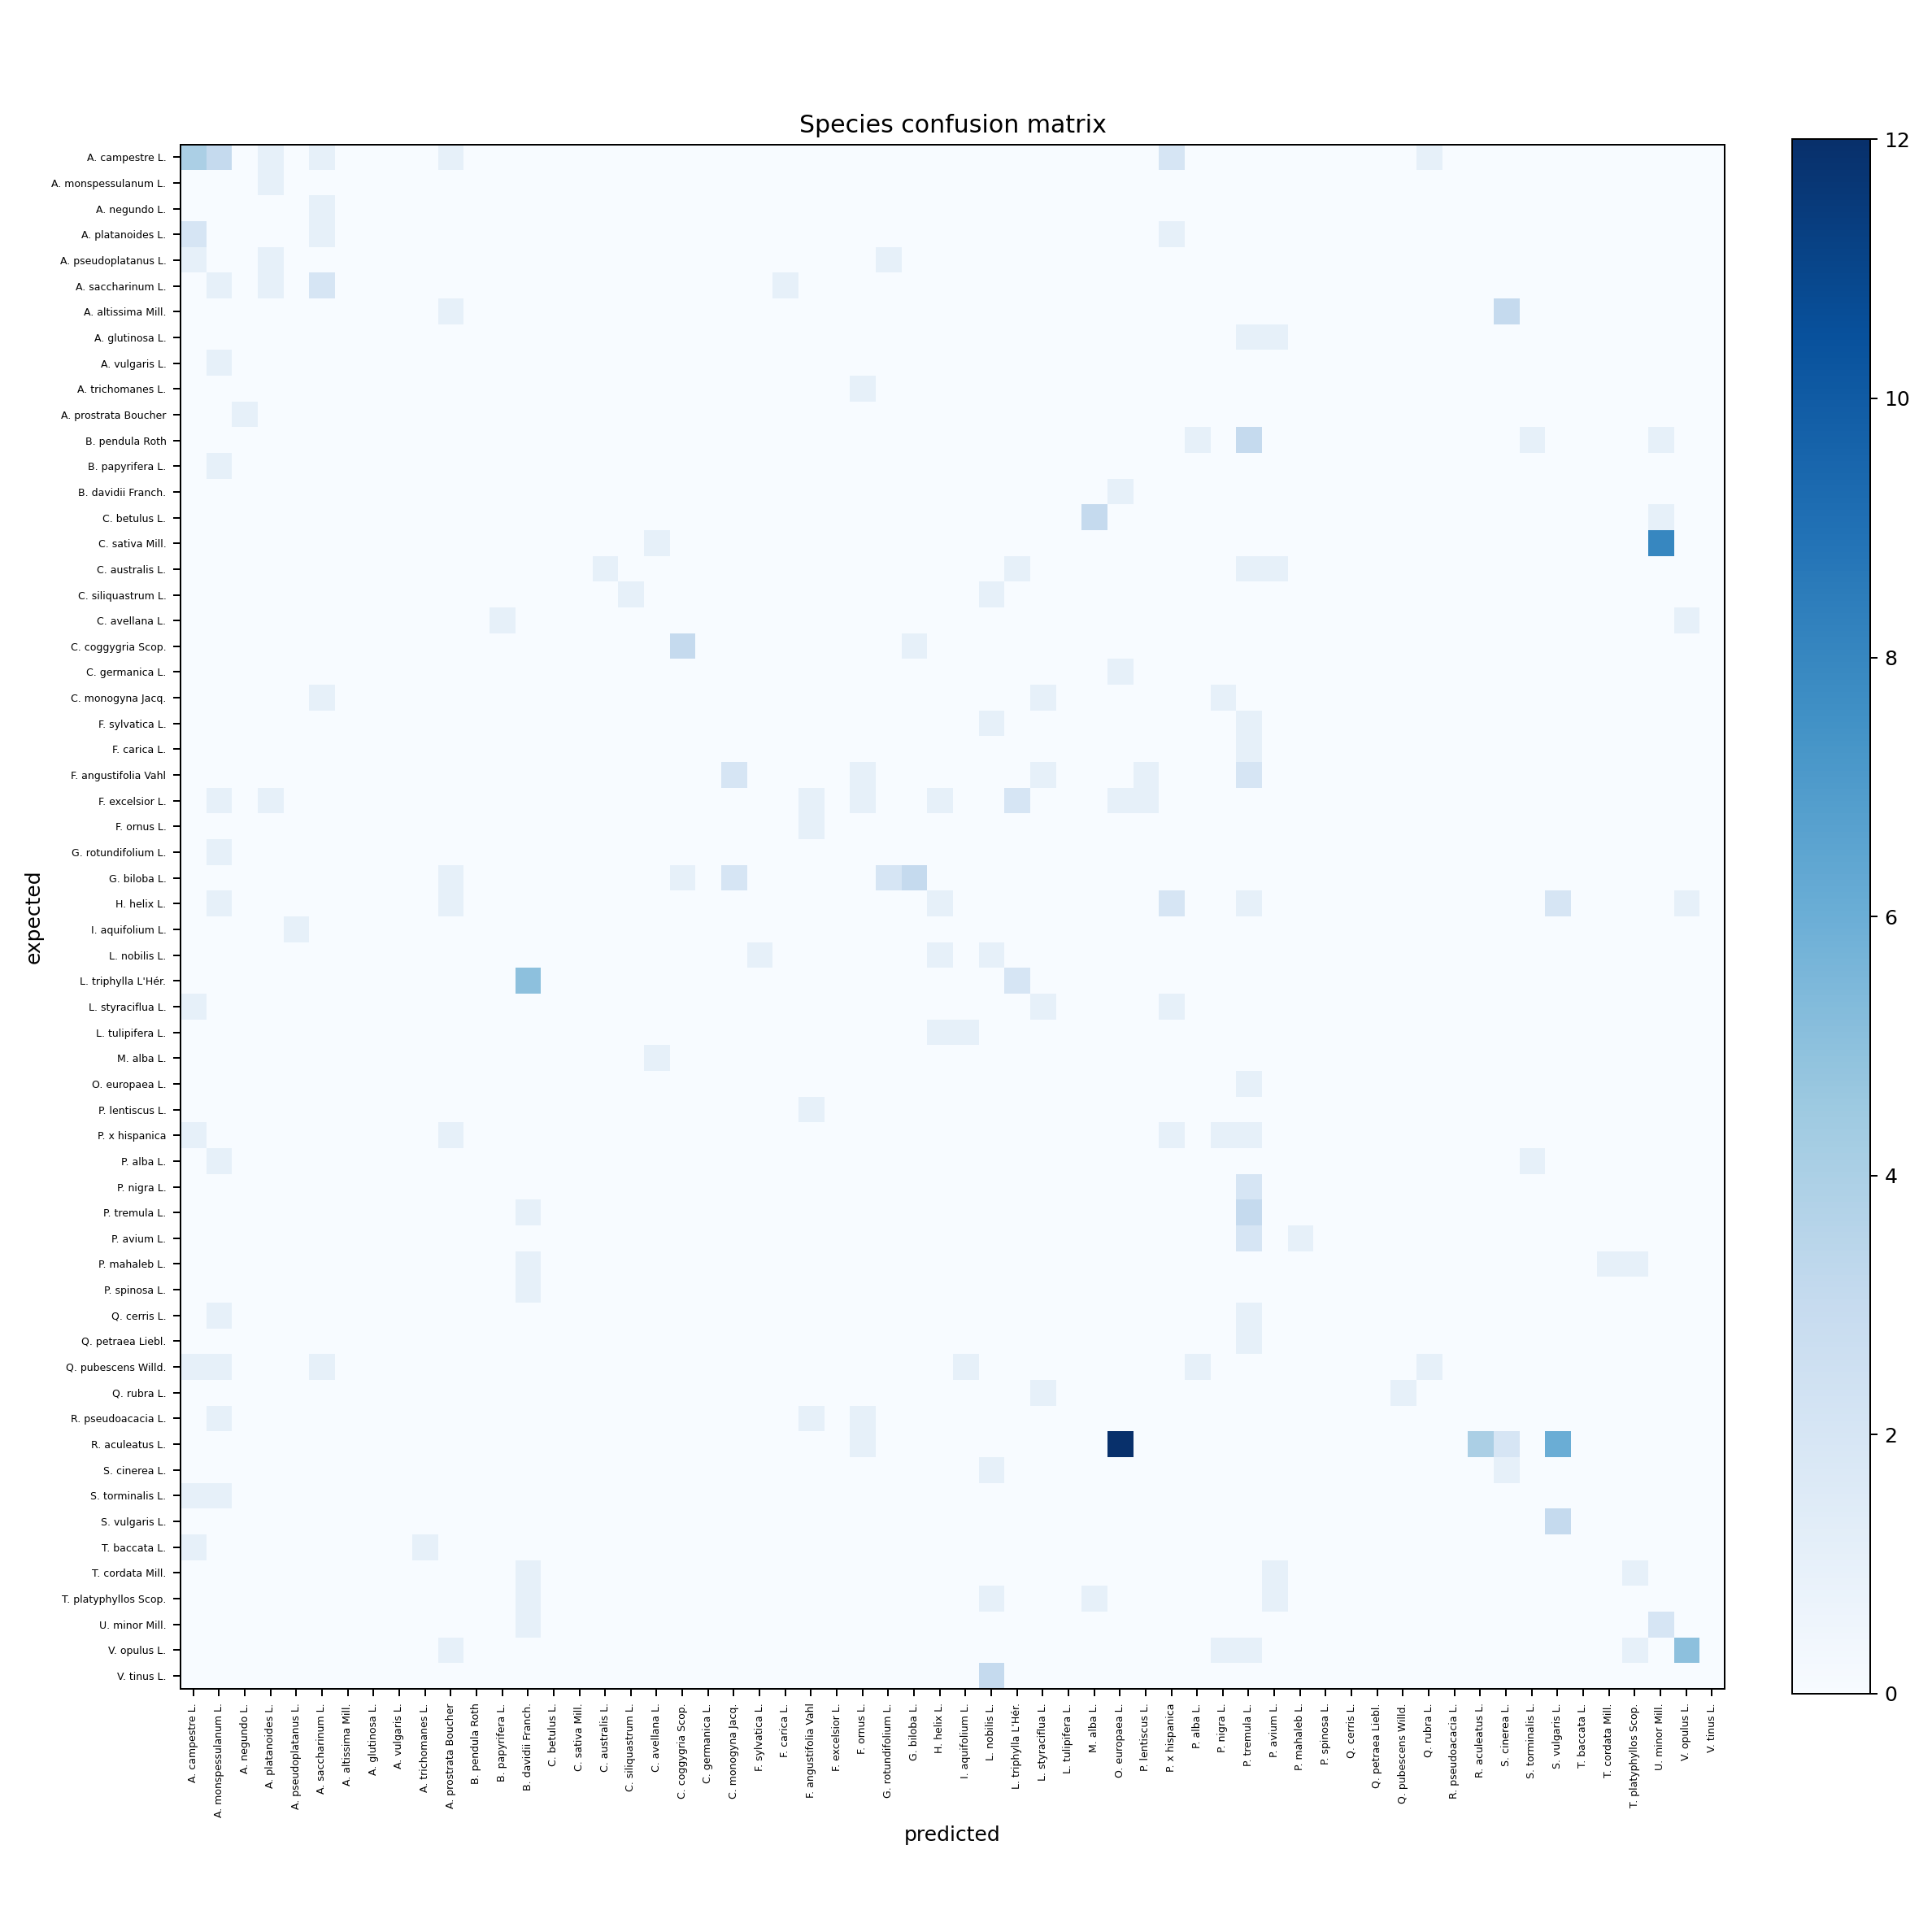

`/content/drive/MyDrive/diploma_diagnostics/species_vgg16_20260521T000620Z/species_rank_histogram.png`

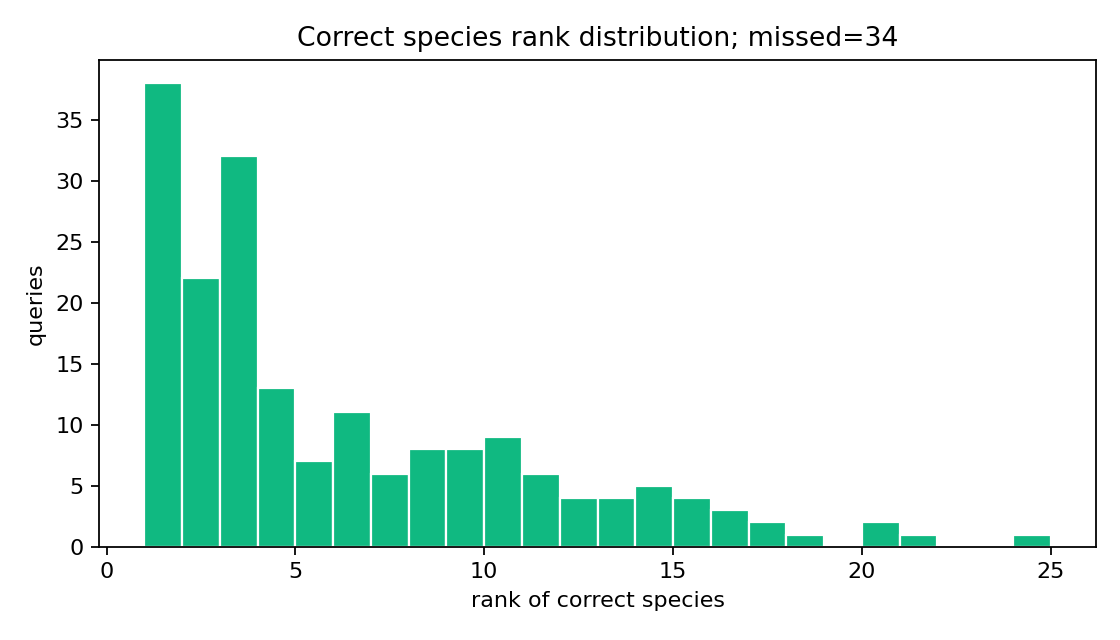

`/content/drive/MyDrive/diploma_diagnostics/species_vgg16_20260521T000620Z/per_species_top1_accuracy.png`

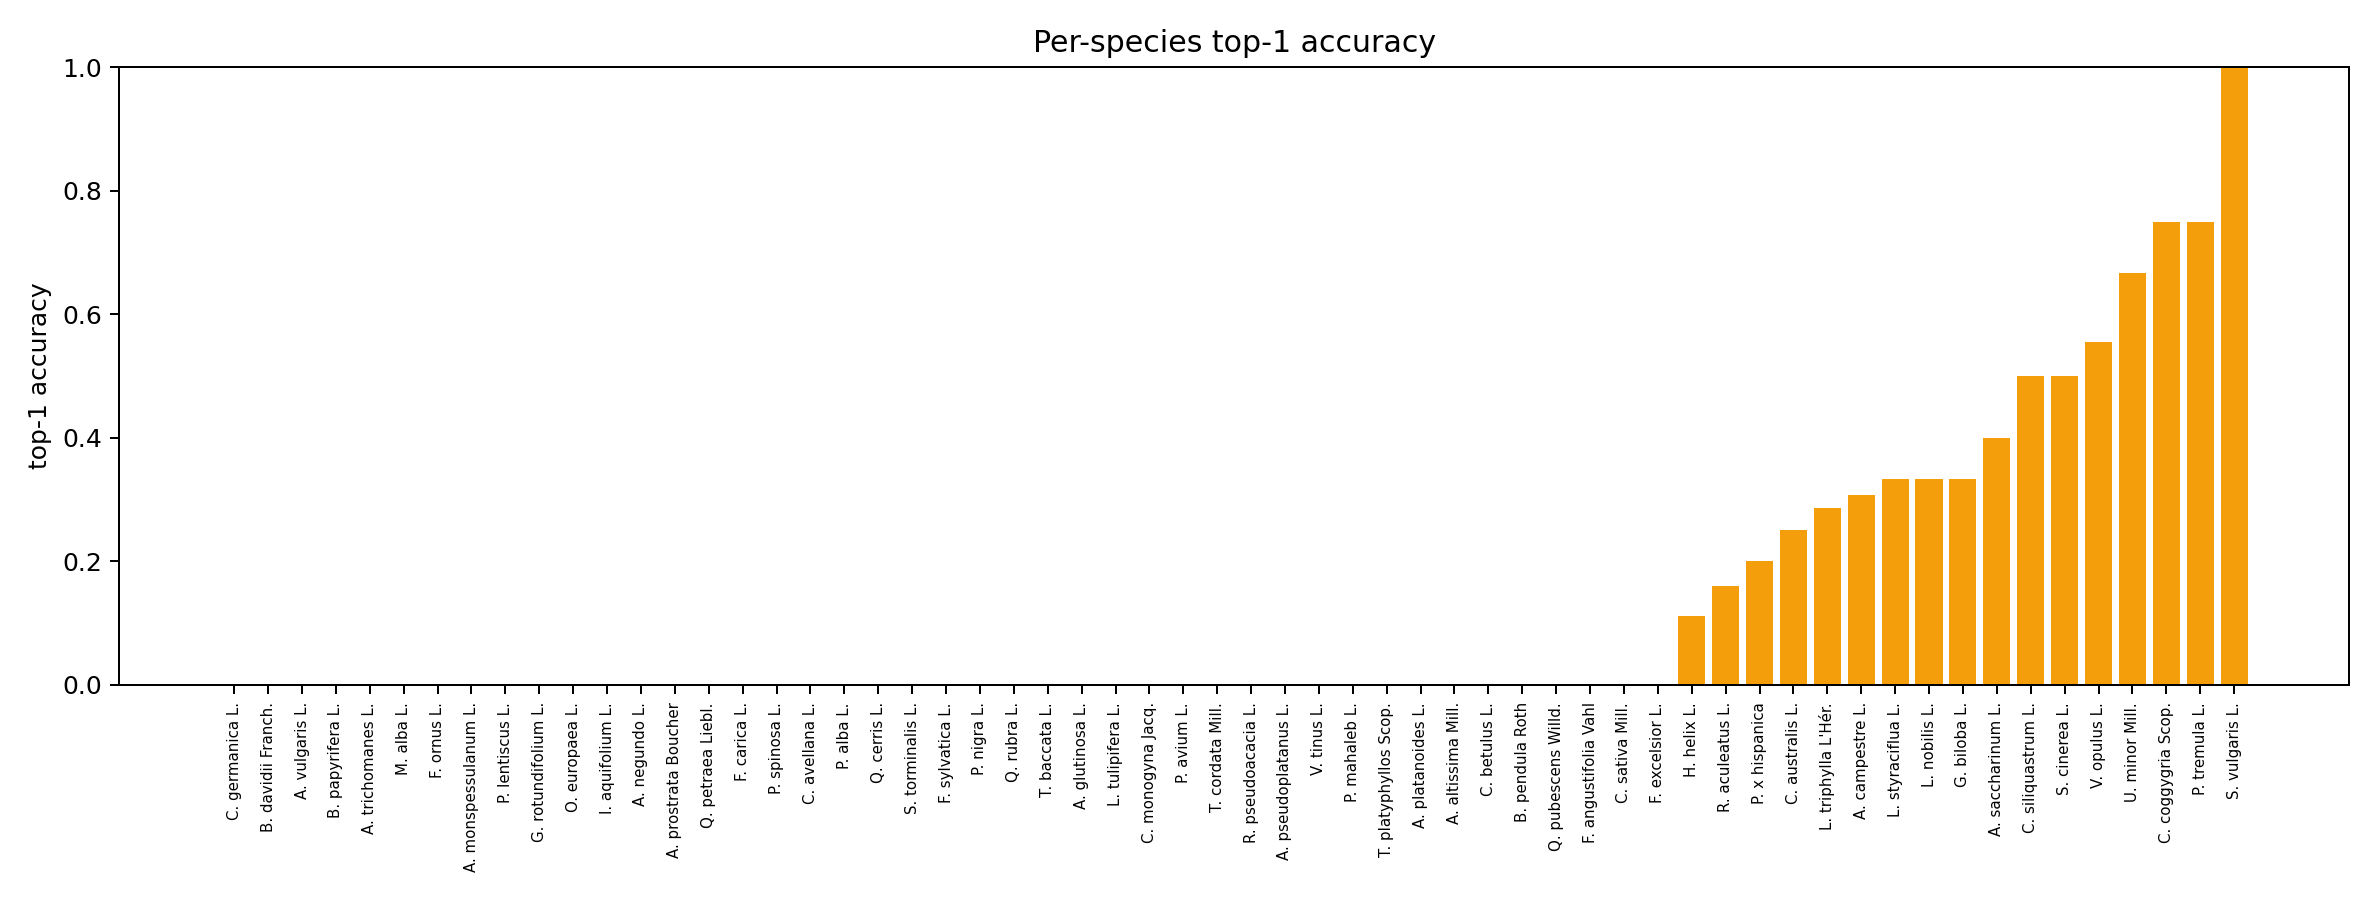

In [12]:
from pathlib import Path
from IPython.display import Image, Markdown, display

BASE = Path('/content/drive/MyDrive/diploma_diagnostics')


def latest_dir(pattern: str) -> Path | None:
    candidates = sorted(BASE.glob(pattern), key=lambda path: path.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


def display_png(path: Path, width: int = 900) -> None:
    if not path.exists():
        display(Markdown(f'`{path}` not found'))
        return
    display(Markdown(f'`{path}`'))
    display(Image(filename=str(path), width=width))


groups = [
    (
        'Grid summary',
        latest_dir('species_vgg16_grid_*'),
        [
            'species_grid_l1_l1_mean_curves.png',
            'species_grid_best_settings.png',
        ],
    ),
    (
        'Best practical S-CNN result: R=15, L1/L1/mean',
        latest_dir('species_vgg16_best_l1_l1_mean_R15_*'),
        [
            'topk_species_accuracy.png',
            'species_confusion_matrix.png',
            'species_rank_histogram.png',
            'per_species_top1_accuracy.png',
        ],
    ),
    (
        'Training curves',
        BASE / 'training_curves',
        [
            'training_loss_curves.png',
            'training_accuracy_curves.png',
        ],
    ),
    (
        'Previous two-stage evaluation artifacts',
        latest_dir('species_vgg16_20*'),
        [
            'topk_species_accuracy.png',
            'species_confusion_matrix.png',
            'species_rank_histogram.png',
            'per_species_top1_accuracy.png',
        ],
    ),
]

for title, directory, filenames in groups:
    display(Markdown(f'### {title}'))
    if directory is None or not directory.exists():
        display(Markdown('No artifact directory found yet.'))
        continue
    display(Markdown(f'Directory: `{directory}`'))
    for filename in filenames:
        display_png(directory / filename)
